In [2]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Импортируем LightGBM
import lightgbm as lgb

# Используем Pipeline и SMOTE из imblearn для корректной работы с ресемплингом внутри Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Функции для Предобработки и Сборки Пайплайна (как были раньше) ---

def create_preprocessing_pipeline():
    """Создает пайплайн предобработки (масштабирование Time и Amount)."""
    numeric_features = ['Time', 'Amount']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), numeric_features)
        ],
        remainder='passthrough' # Оставляет остальные колонки (V1-V28) без изменений
    )
    return preprocessor

def create_complete_fraud_pipeline(model, use_smote=False):
    """
    Создает полный пайплайн: Предобработка -> (SMOTE) -> Модель.

    Args:
        model: Экземпляр модели Scikit-learn (или совместимой, как LGBMClassifier).
        use_smote (bool): Использовать ли SMOTE для ресемплинга *перед* шагом модели.

    Returns:
        imblearn.pipeline.Pipeline: Готовый к обучению пайплайн (всегда используем ImbPipeline для единообразия).
                                     Если use_smote=False, шаг SMOTE просто отсутствует.
    """
    preprocessor = create_preprocessing_pipeline()

    pipeline_steps = [('preprocessor', preprocessor)]

    if use_smote:
        pipeline_steps.append(('sampler', SMOTE(random_state=42, n_jobs=-1))) # n_jobs=-1 для SMOTE, если возможно

    # Добавляем классификатор в конец
    pipeline_steps.append(('classifier', model))

    # Всегда возвращаем ImbPipeline, он умеет работать и без шага sampler
    return ImbPipeline(steps=pipeline_steps)


# --- Функция для создания Пайплайна с Logistic Regression (как была, но уточнена) ---

def create_logistic_regression_pipeline(use_smote=False, model_params=None):
     """
     Создает пайплайн с Logistic Regression.

     Args:
         use_smote (bool): Использовать ли SMOTE перед моделью.
         model_params (dict, optional): Параметры для LogisticRegression.
                                       Если use_smote=True, class_weight НЕ будет 'balanced' по умолчанию.
                                       Если use_smote=False, class_weight будет 'balanced' по умолчанию.
     Returns:
         imblearn.pipeline.Pipeline: Готовый к обучению пайплайн.
     """
     default_params = {'random_state': 42, 'solver': 'liblinear', 'max_iter': 1000} # Увеличил max_iter на всякий случай

     # Важно: Не используем class_weight='balanced' одновременно со SMOTE
     if not use_smote:
          default_params['class_weight'] = 'balanced'
     # else: # Если SMOTE используется, class_weight будет None по умолчанию

     final_model_params = default_params.copy()
     if model_params:
          final_model_params.update(model_params) # Пользовательские параметры переопределяют дефолтные

     model = LogisticRegression(**final_model_params)
     return create_complete_fraud_pipeline(model, use_smote)


# --- НОВАЯ Функция для создания Пайплайна с LGBMClassifier ---

def create_lgbm_pipeline(use_smote=False, model_params=None):
    """
    Создает пайплайн с LGBMClassifier.

    Args:
        use_smote (bool): Использовать ли SMOTE перед моделью.
        model_params (dict, optional): Параметры для LGBMClassifier.
                                      Если use_smote=True, class_weight НЕ будет 'balanced' по умолчанию.
                                      Если use_smote=False, class_weight будет 'balanced' по умолчанию.
    Returns:
        imblearn.pipeline.Pipeline: Готовый к обучению пайплайн.
    """
    default_params = {
        'random_state': 42,
        'n_jobs': -1 # Использовать все ядра процессора
        # 'objective': 'binary', # Обычно определяется автоматически для Classifier
        # 'metric': 'auc',     # Можно указать метрику для early stopping, если используется fit(eval_set=...)
    }

    # Важно: Не используем class_weight='balanced' одновременно со SMOTE
    if not use_smote:
        default_params['class_weight'] = 'balanced'
    # else: # Если SMOTE используется, class_weight будет None по умолчанию

    final_model_params = default_params.copy()
    if model_params:
        final_model_params.update(model_params) # Пользовательские параметры переопределяют дефолтные

    # Создаем модель LGBM
    model = lgb.LGBMClassifier(**final_model_params)

    # Собираем полный пайплайн
    return create_complete_fraud_pipeline(model, use_smote)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_curve, f1_score, classification_report, roc_auc_score, average_precision_score

In [4]:
data = pd.read_csv('../data/creditcard.csv')

X = data.drop('Class',axis=1)
y = data['Class']

1. Загрузка данных...
Данные загружены: 284807 строк, 31 столбцов
Распределение классов:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

2. Разделение данных на Train/Test...
Обучающая выборка: (213605, 30), Тестовая выборка: (71202, 30)
Доля 'Fraud' в Train: 0.0017, в Test: 0.0017

3. Создание и обучение LGBM пайплайна (class_weight='balanced')...
[LightGBM] [Info] Number of positive: 369, number of negative: 213236
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015757 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 213605, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Пайплайн обучен.

4. Получение предсказаний на тестовой выборке...

5. Оценка производительности модели:

--- Classification Report ---
 

c:\Users\79103\vs_code_repos\Fraud\.fraud\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\79103\vs_code_repos\Fraud\.fraud\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\79103\vs_code_repos\Fraud\.fraud\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\79103\vs_code_repos\Fraud\.fraud\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


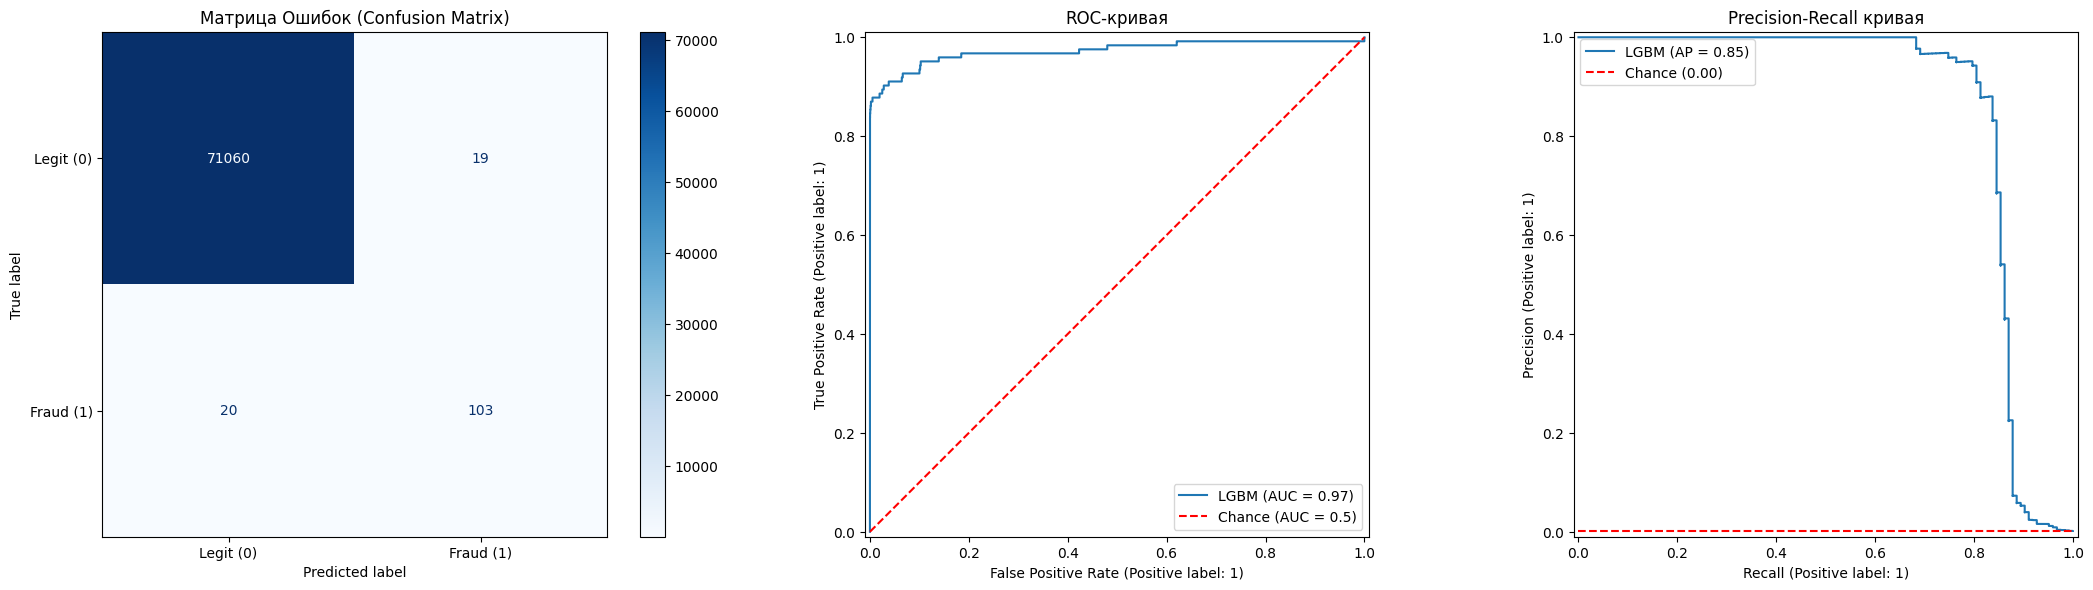


Оценка завершена.


In [5]:
# --- Основной блок: Загрузка, Обучение, Оценка ---
if __name__ == '__main__':
    print("1. Загрузка данных...")
    DATA_PATH = '../data/creditcard.csv' # <-- УКАЖИТЕ ПРАВИЛЬНЫЙ ПУТЬ К ФАЙЛУ
    try:
        df = pd.read_csv(DATA_PATH)
    except FileNotFoundError:
        print(f"ОШИБКА: Файл не найден по пути '{DATA_PATH}'")
        print("Пожалуйста, убедитесь, что файл creditcard.csv находится в папке 'data' или укажите правильный путь.")
        exit()

    print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
    print(f"Распределение классов:\n{df['Class'].value_counts(normalize=True)}")

    # 2. Подготовка данных
    X = df.drop('Class', axis=1)
    y = df['Class'] # Целевая переменная (0 - легитимная, 1 - мошенничество)

    # 3. Разделение на обучающую и тестовую выборки
    print("\n2. Разделение данных на Train/Test...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25, # Используем 25% для теста (можно 20%)
        random_state=42,
        stratify=y # Важно для сохранения пропорции классов
    )
    print(f"Обучающая выборка: {X_train.shape}, Тестовая выборка: {X_test.shape}")
    print(f"Доля 'Fraud' в Train: {y_train.mean():.4f}, в Test: {y_test.mean():.4f}")

    # 4. Создание и обучение пайплайна
    print("\n3. Создание и обучение LGBM пайплайна (class_weight='balanced')...")
    # Выбираем конфигурацию пайплайна для оценки
    # Можно попробовать use_smote=True или другие параметры/модели
    pipeline_to_evaluate = create_lgbm_pipeline(use_smote=False)

    pipeline_to_evaluate.fit(X_train, y_train)
    print("Пайплайн обучен.")

    # 5. Получение предсказаний на тестовой выборке
    print("\n4. Получение предсказаний на тестовой выборке...")
    y_pred = pipeline_to_evaluate.predict(X_test)
    # Получаем вероятности для класса 1 (Fraud) - нужно для AUC метрик
    y_proba_fraud = pipeline_to_evaluate.predict_proba(X_test)[:, 1]

    # 6. Оценка производительности
    print("\n5. Оценка производительности модели:")

    # --- Классификационный отчет ---
    print("\n--- Classification Report ---")
    # digits=3 увеличивает точность отображения до 3 знаков после запятой
    print(classification_report(y_test, y_pred, digits=3, target_names=['Legit (0)', 'Fraud (1)']))

    # --- Основные метрики ---
    # Рассчитаем ключевые метрики отдельно для наглядности
    recall_fraud = recall_score(y_test, y_pred, pos_label=1)
    precision_fraud = precision_score(y_test, y_pred, pos_label=1)
    f1_fraud = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_proba_fraud)
    pr_auc = average_precision_score(y_test, y_proba_fraud)

    print("--- Ключевые метрики для класса 'Fraud (1)' ---")
    print(f"Recall (Полнота):           {recall_fraud:.3f}")
    print(f"Precision (Точность):       {precision_fraud:.3f}")
    print(f"F1-Score:                   {f1_fraud:.3f}")
    print(f"ROC AUC:                    {roc_auc:.3f}")
    print(f"Precision-Recall AUC (PR AUC): {pr_auc:.3f}")


    # --- Визуализация ---
    print("\n6. Визуализация результатов...")

    # Создаем фигуру с тремя подграфиками
    fig, axes = plt.subplots(1, 3, figsize=(22, 6)) # 1 строка, 3 столбца

    # --- Матрица ошибок ---
    cm = confusion_matrix(y_test, y_pred)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit (0)', 'Fraud (1)'])
    disp_cm.plot(ax=axes[0], cmap='Blues')
    axes[0].set_title('Матрица Ошибок (Confusion Matrix)')

    # --- ROC-кривая ---
    roc_display = RocCurveDisplay.from_estimator(pipeline_to_evaluate, X_test, y_test, ax=axes[1], name='LGBM')
    axes[1].plot([0, 1], [0, 1], 'r--', label='Chance (AUC = 0.5)') # Линия случайного угадывания
    axes[1].set_title('ROC-кривая')
    axes[1].legend()

    # --- Precision-Recall кривая ---
    pr_display = PrecisionRecallDisplay.from_estimator(pipeline_to_evaluate, X_test, y_test, ax=axes[2], name='LGBM')
    # Доля позитивного класса (линия случайного угадывания для PR кривой)
    chance_level = y_test.mean()
    axes[2].plot([0, 1], [chance_level, chance_level], 'r--', label=f'Chance ({chance_level:.2f})')
    axes[2].set_title('Precision-Recall кривая')
    axes[2].legend()


    plt.tight_layout() # Чтобы заголовки и метки не перекрывались
    plt.show() # Показать все графики

    print("\nОценка завершена.")